# Lab 4 - (Stochastic) Gradient Descent and Linear Regression
The goal of this lab is to deepen you understanding of gradient descent and linear regression.

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## Task 1: Multiple Linear Regression to Predict House Price

In [24]:
# Load data for linear regression
housing = pd.read_csv('Housing.csv')
# Remove rows with empty fields
housing = housing.dropna()
print(housing.shape)

(545, 13)


In [25]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [26]:
# Remove outliers using Boolean mask
columns_to_check = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return (df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)

mask = (remove_outliers(housing, 'price') & 
        remove_outliers(housing, 'area') & 
        remove_outliers(housing, 'bedrooms') & 
        remove_outliers(housing, 'bathrooms') & 
        remove_outliers(housing, 'stories') & 
        remove_outliers(housing, 'parking'))

housing_clean = housing[mask]
print(f"Shape after removing outliers: {housing_clean.shape}")

Shape after removing outliers: (463, 13)


In [27]:
X = housing_clean[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = housing_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training: {len(X_train)}, Testing: {len(X_test)}")

Training: 370, Testing: 93


In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [594093.52158861  81066.78254253 417697.87970189 267060.08823295
 267044.24879719]
Intercept: 4349052.702702703


In [47]:
y_pred = model.predict(X_test_scaled)

# Calculate MSE and R²
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:,.2f}")
print(f"R²: {r2:.4f}")

MSE: 1,300,994,366,728.09
R²: 0.5003


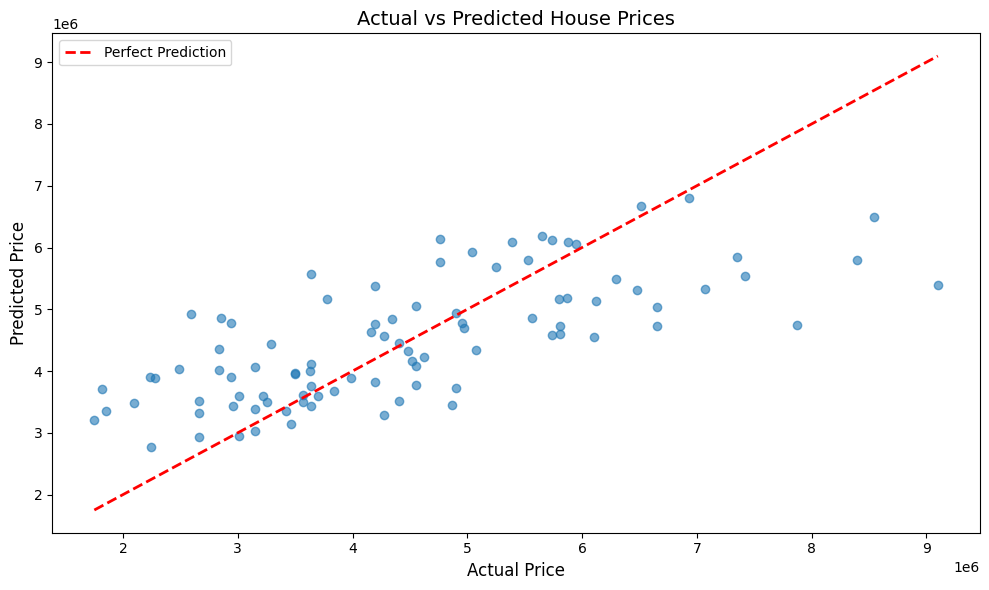


Prediction Quality:
- The R² score of 0.5003 indicates that the model explains 50.03% of the variance in house prices.
- The RMSE of 1,140,611.40 represents the average prediction error in price units.
- Some scatter around the line suggests the model captures the general trend but has room for improvement.


In [54]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.title('Actual vs Predicted House Prices', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

print("\nPrediction Quality:")
print(f"- The R² score of {r2:.4f} indicates that the model explains {r2*100:.2f}% of the variance in house prices.")
print(f"- The RMSE of {np.sqrt(mse):,.2f} represents the average prediction error in price units.")
print("- Some scatter around the line suggests the model captures the general trend but has room for improvement.")

### Fitted Linear Regression Model

**Model Equation:**

$$\text{price} = \beta_0 + \beta_1 \cdot \text{area} + \beta_2 \cdot \text{bedrooms} + \beta_3 \cdot \text{bathrooms} + \beta_4 \cdot \text{stories} + \beta_5 \cdot \text{parking}$$

**Features Used:** area, bedrooms, bathrooms, stories, parking

Model Performance:
- R² Score: Shows how well the model fits the data (closer to 1 is better)
- MSE: Measures prediction error (lower is better)

Steps:
1. Loaded and cleaned the housing data
2. Removed outliers using the IQR method
3. Split data into 80% training and 20% testing
4. Scaled features using StandardScaler
5. Trained the model and evaluated on test data

## Task 2: Locally Weighted Linear Regression 

In [57]:
tips = pd.read_csv('tips.csv')
X = tips[["total_bill", "size"]].to_numpy()
y = tips["tip"].to_numpy()
print(f"Data shape: X={X.shape}, y={y.shape}")

Data shape: X=(244, 2), y=(244,)


In [58]:
def locally_weighted_lr(X_train, y_train, x_query, tau):
    """
    Locally weighted linear regression for a single query point.
    
    Parameters:
    - X_train: Training features (n_samples, n_features)
    - y_train: Training targets (n_samples,)
    - x_query: Query point (n_features,)
    - tau: Bandwidth parameter
    
    Returns:
    - Predicted value for x_query
    """
    m = X_train.shape[0]
    
    weights = np.zeros(m)
    for i in range(m):
        diff = x_query - X_train[i]
        weights[i] = np.exp(-np.dot(diff, diff) / (2 * tau**2))
    
    W = np.diag(weights)
    X_b = np.c_[np.ones(m), X_train]
    x_query_b = np.r_[1, x_query]
    theta = np.linalg.pinv(X_b.T @ W @ X_b) @ (X_b.T @ W @ y_train)
    
    return x_query_b @ theta

def predict_lwlr(X_train, y_train, X_test, tau):
    """Predict for all test points using locally weighted linear regression."""
    predictions = np.zeros(len(X_test))
    for i, x in enumerate(X_test):
        predictions[i] = locally_weighted_lr(X_train, y_train, x, tau)
    return predictions

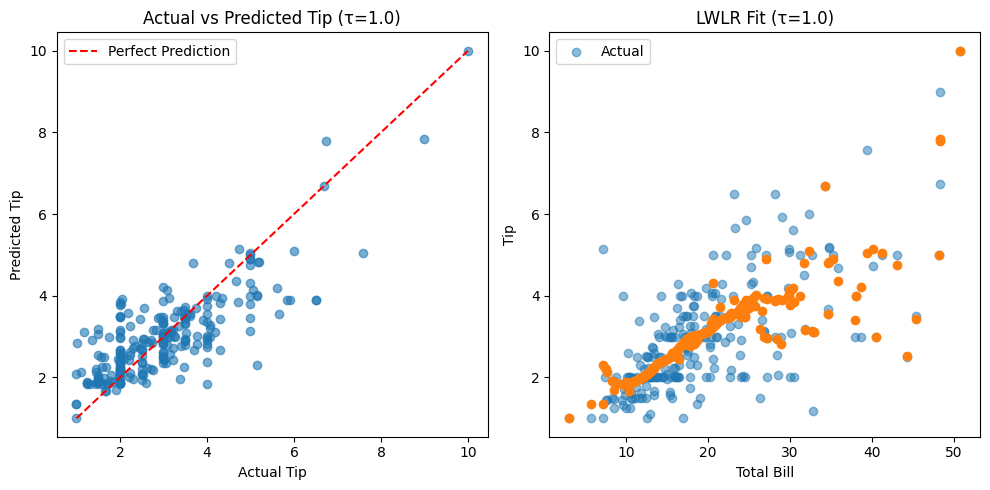

In [62]:
tau = 1.0 
y_pred_lwlr = predict_lwlr(X, y, X, tau)

# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred_lwlr, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Tip')
plt.ylabel('Predicted Tip')
plt.title(f'Actual vs Predicted Tip (τ={tau})')
plt.legend()

plt.subplot(1, 2, 2)
sorted_idx = np.argsort(X[:, 0])
plt.scatter(X[:, 0], y, alpha=0.5, label='Actual')
plt.scatter(X[:, 0], y_pred_lwlr)
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title(f'LWLR Fit (τ={tau})')
plt.legend()

plt.tight_layout()
plt.show()

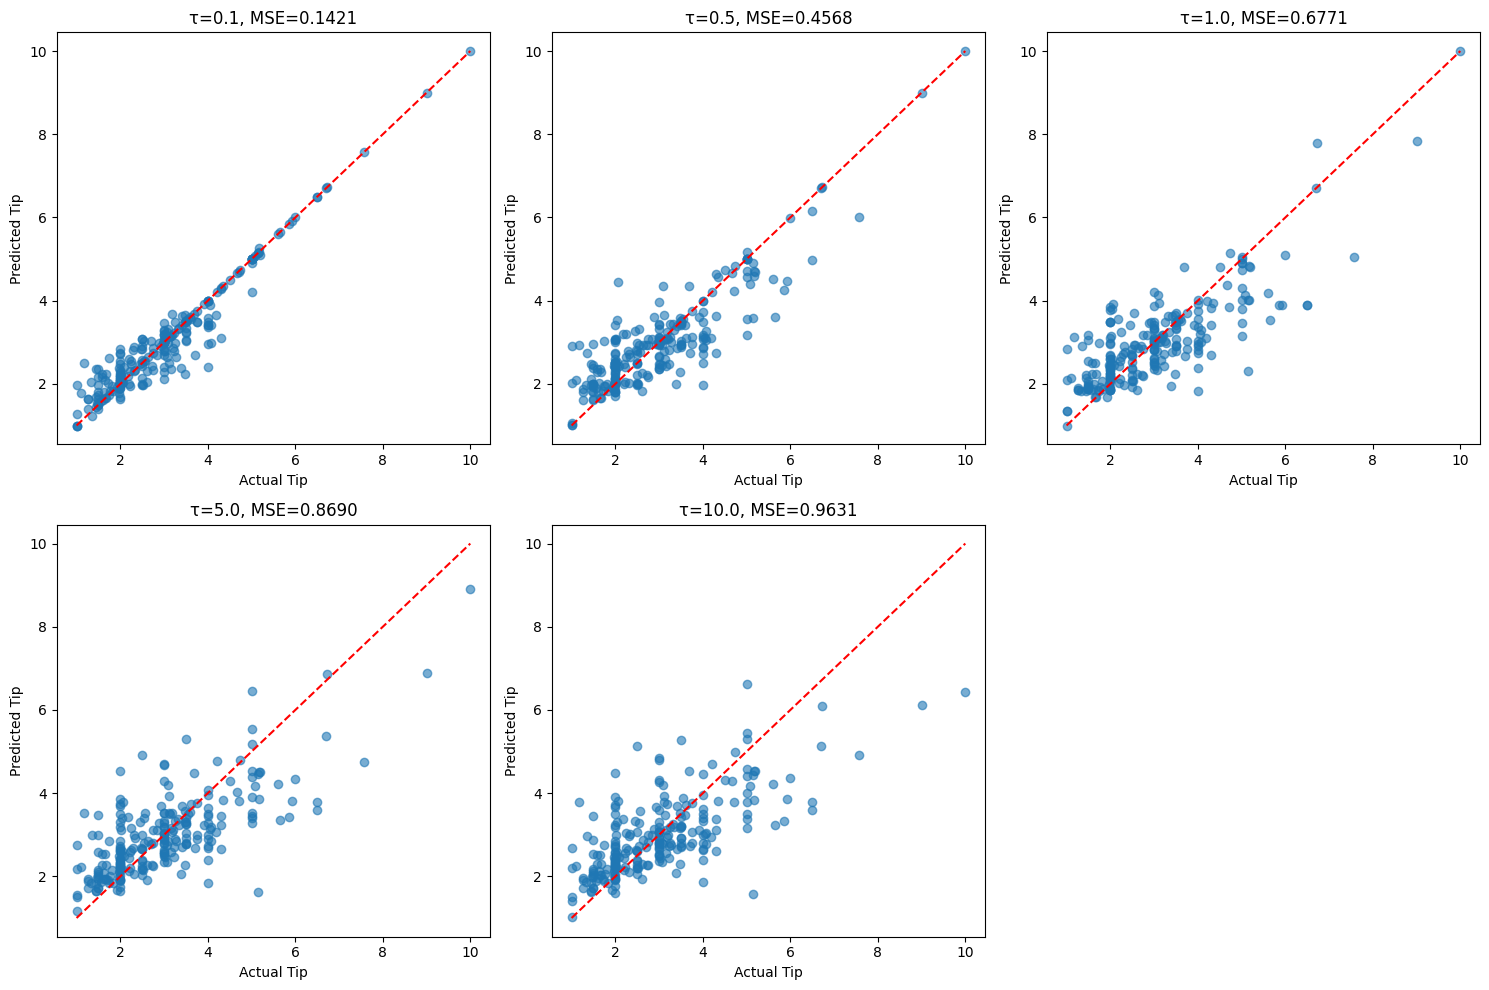

In [64]:
# Compare different τ values
tau_values = [0.1, 0.5, 1.0, 5.0, 10.0]

plt.figure(figsize=(15, 10))
for i, tau in enumerate(tau_values):
    y_pred = predict_lwlr(X, y, X, tau)
    mse = mean_squared_error(y, y_pred)
    
    plt.subplot(2, 3, i+1)
    plt.scatter(y, y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel('Actual Tip')
    plt.ylabel('Predicted Tip')
    plt.title(f'τ={tau}, MSE={mse:.4f}')
plt.tight_layout()
plt.show()

### Discussion

Sensitivity to τ :
- Smaller τ (e.g., 0.1): More localized influence, focuses on closer neighbors. Can lead to overfitting as the model fits noise in the data.
- Larger τ (e.g., 10.0): Wider influence, includes farther neighbors. Approaches standard linear regression, may underfit if data has local patterns.

Disadvantage of Locally Weighted Linear Regression:
- Computational inefficiency: For each new prediction, LWLR must solve a weighted least squares problem using all training data. Much slower for large datasets or real-time predictions.

## Bonus Task: GD and SGD

In [65]:
data = pd.read_csv('penguins.csv')
data = data.dropna()

X_penguin = data['flipper_length_mm'].values.reshape(-1, 1)
y_penguin = data['body_mass_g'].values

# Standardize to avoid overflow
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_penguin).flatten()
y_scaled = scaler_y.fit_transform(y_penguin.reshape(-1, 1)).flatten()

print(f"Data shape: X={X_scaled.shape}, y={y_scaled.shape}")

Data shape: X=(333,), y=(333,)


In [66]:
# Implement Gradient Descent
def gradient_descent(X, y, lr=0.01, n_iter=1000, theta_init=None):
    """
    Gradient Descent for linear regression.
    
    Parameters:
    - X: Feature array (n_samples,)
    - y: Target array (n_samples,)
    - lr: Learning rate
    - n_iter: Number of iterations
    - theta_init: Initial parameters [theta0, theta1]
    
    Returns:
    - theta: Learned parameters [theta0, theta1]
    - loss_history: List of loss values at each iteration
    """
    m = len(y)
    
    # Initialize parameters
    if theta_init is None:
        theta = np.zeros(2)  # [intercept, slope]
    else:
        theta = np.array(theta_init)
    
    loss_history = []
    
    for i in range(n_iter):
        # Predictions: y_hat = theta0 + theta1 * X
        y_pred = theta[0] + theta[1] * X
        
        # Compute loss: MSE = (1/m) * sum((y - y_hat)^2)
        loss = np.mean((y - y_pred) ** 2)
        loss_history.append(loss)
        
        # Compute gradients
        grad_theta0 = -2 * np.mean(y - y_pred)
        grad_theta1 = -2 * np.mean((y - y_pred) * X)
        
        # Update parameters
        theta[0] -= lr * grad_theta0
        theta[1] -= lr * grad_theta1
    
    return theta, loss_history

In [67]:
# Implement Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, lr=0.01, n_iter=1000, theta_init=None):
    """
    Stochastic Gradient Descent for linear regression.
    
    Parameters:
    - X: Feature array (n_samples,)
    - y: Target array (n_samples,)
    - lr: Learning rate
    - n_iter: Number of iterations
    - theta_init: Initial parameters [theta0, theta1]
    
    Returns:
    - theta: Learned parameters [theta0, theta1]
    - loss_history: List of loss values at each iteration
    """
    m = len(y)
    
    # Initialize parameters
    if theta_init is None:
        theta = np.zeros(2)
    else:
        theta = np.array(theta_init)
    
    loss_history = []
    
    for i in range(n_iter):
        # Randomly shuffle data indices
        indices = np.random.permutation(m)
        
        for j in indices:
            # Single sample prediction
            y_pred_j = theta[0] + theta[1] * X[j]
            
            # Compute gradients for single sample
            grad_theta0 = -2 * (y[j] - y_pred_j)
            grad_theta1 = -2 * (y[j] - y_pred_j) * X[j]
            
            # Update parameters
            theta[0] -= lr * grad_theta0
            theta[1] -= lr * grad_theta1
        
        # Compute loss after each epoch
        y_pred = theta[0] + theta[1] * X
        loss = np.mean((y - y_pred) ** 2)
        loss_history.append(loss)
    
    return theta, loss_history

In [71]:
# Fit linear models
lr = 0.1
n_iter = 100

theta_gd, loss_gd = gradient_descent(X_scaled, y_scaled, lr=lr, n_iter=n_iter)
print(f"GD: theta0={theta_gd[0]:.4f}, theta1={theta_gd[1]:.4f}")

np.random.seed(42)
theta_sgd, loss_sgd = stochastic_gradient_descent(X_scaled, y_scaled, lr=0.01, n_iter=n_iter)
print(f"SGD: theta0={theta_sgd[0]:.4f}, theta1={theta_sgd[1]:.4f}")

GD: theta0=-0.0000, theta1=0.8730
SGD: theta0=0.0376, theta1=0.9375


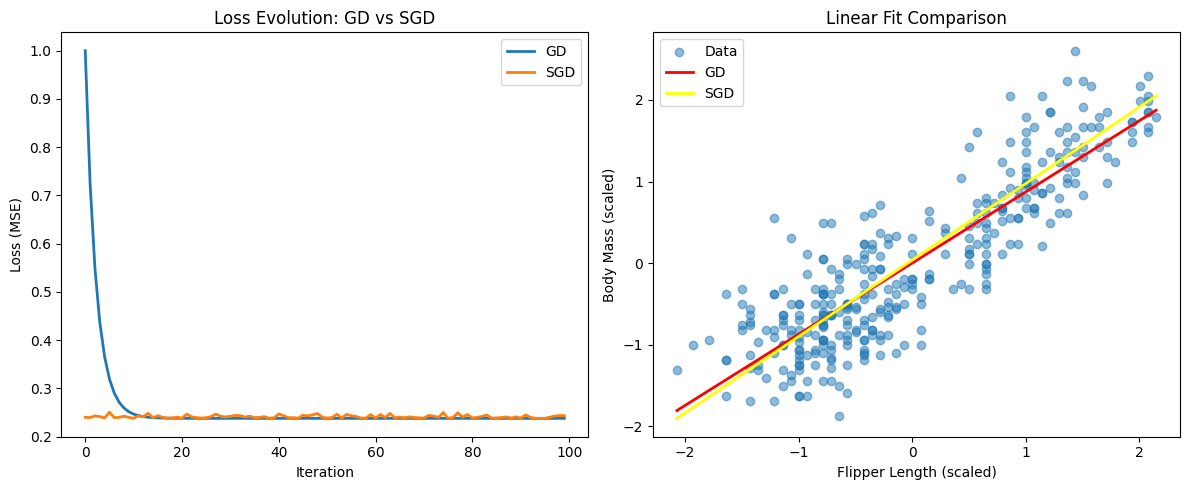

Final MSE - GD: 0.237908
Final MSE - SGD: 0.243481


In [74]:
# Plot loss evolution
plt.figure(figsize=(12, 5))

# Plot loss curves
plt.subplot(1, 2, 1)
plt.plot(loss_gd, label='GD', linewidth=2)
plt.plot(loss_sgd, label='SGD', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Loss Evolution: GD vs SGD')
plt.legend()

# Plot fitted lines
plt.subplot(1, 2, 2)
plt.scatter(X_scaled, y_scaled, alpha=0.5, label='Data')
x_line = np.linspace(X_scaled.min(), X_scaled.max(), 100)
plt.plot(x_line, theta_gd[0] + theta_gd[1] * x_line, 'red', label=f'GD', linewidth=2)
plt.plot(x_line, theta_sgd[0] + theta_sgd[1] * x_line, 'yellow', label=f'SGD', linewidth=2)
plt.xlabel('Flipper Length (scaled)')
plt.ylabel('Body Mass (scaled)')
plt.title('Linear Fit Comparison')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate MSE
y_pred_gd = theta_gd[0] + theta_gd[1] * X_scaled
y_pred_sgd = theta_sgd[0] + theta_sgd[1] * X_scaled
mse_gd = mean_squared_error(y_scaled, y_pred_gd)
mse_sgd = mean_squared_error(y_scaled, y_pred_sgd)

print(f"Final MSE - GD: {mse_gd:.6f}")
print(f"Final MSE - SGD: {mse_sgd:.6f}")

### Discussion

Loss Function:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (y_i - \theta_0 - \theta_1 x_i)^2$$

Observations - GD vs SGD:
1. GD shows smooth decrease in loss since it uses the entire dataset to compute gradients
2. SGD shows noisier convergence due to single-sample gradient updates, but can escape local minima


Overflow:
- Overflow error was encountered when using raw features
- Solution adopted: Used StandardScaler to standardize both features and target to have zero mean and unit variance
- Learning rate was also tuned to ensure stable convergence